In [1]:
# 1. Analysis Plan
#    H4 – Pearson correlation
#    H5 – Pearson correlation
#    H6 – Multiple linear regression
#    H7 – Exploratory factor analysis

# 2. Data Analysis
#    Brief Assessment 2 cleaning recap
#    Correct reverse coding
#    H4/H5 correlation
#    H6 regression + assumptions
#    H7 EFA + assumptions/extraction/retention

# 3. Results
#    H1 – t-test from Assessment 2
#    H2 – ANOVA from Assessment 2
#    H3 – Chi-square from Assessment 2
#    H4 – Correlation
#    H5 – Correlation
#    H6 – Multiple regression
#    H7 – EFA

# 4. Discussion
#    Overall story
#    Limitations
#    Validity
#    Practical recommendation
#    Future research direction

# 5. References

In [2]:
# # Assessment-3 :  Research  Project Report

# This notebook covers the statistical work needed for MR502 Assessment 3.  
# I reuse the cleaned workplace survey data from the Assessment 2.

# This analysis is including,
# H1: Independent-sample t-test
# H2: One-way ANOVA
# H3: Chi-square test
# H4: Pearson correlation
# H5: Pearson correlation
# H6: Multiple linear regression
# H7: Exploratory factor analysis

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from statsmodels.multivariate.factor import Factor, rotate_factors

In [4]:
# Load cleaned dataset - from Assesment 2
df = pd.read_csv("data/cleaned_workplace_survey.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (320, 26)


,employee_id,age,gender,department,job_level,education,tenure_years,remote_work_status,weekly_hours_worked,digital_skills_score,...,B3_feel_energetic,B4_burned_out,B5_frustrated_by_job,JS1_overall_satisfied,JS2_job_is_meaningless,JS3_sense_of_pride,JS4_job_is_enjoyable,wellbeing_score,productivity_score,turnover_intention
0,98,37.0,Female,Operations,Mid,Master degree,4.8,Onsite,38.4,3.52,...,4,4.0,2,5,4.0,6,7,64.1,62.8,No
1,217,33.0,Female,IT,Senior,Bachelor degree,1.7,Hybrid,36.7,5.61,...,3,5.0,5,5,5.0,6,5,54.4,68.6,No
2,287,47.0,Female,IT,Mid,Master degree,3.7,Remote,55.7,4.89,...,4,4.0,3,5,3.0,6,7,62.2,74.9,No
3,296,38.0,Male,IT,Mid,Bachelor degree,9.0,Remote,32.9,4.64,...,5,3.0,2,7,2.0,6,6,74.9,74.0,No
4,189,53.0,Female,Operations,Mid,Master degree,4.0,Hybrid,40.0,5.02,...,4,5.0,6,6,4.0,5,6,59.2,69.0,No


In [5]:
df.columns.tolist()

['employee_id',
 'age',
 'gender',
 'department',
 'job_level',
 'education',
 'tenure_years',
 'remote_work_status',
 'weekly_hours_worked',
 'digital_skills_score',
 'tech_adoption_score',
 'RO1_too_much_work',
 'RO2_workload_is_fair',
 'RO3_never_enough_time',
 'B1_emotionally_drained',
 'B2_used_up_end_of_day',
 'B3_feel_energetic',
 'B4_burned_out',
 'B5_frustrated_by_job',
 'JS1_overall_satisfied',
 'JS2_job_is_meaningless',
 'JS3_sense_of_pride',
 'JS4_job_is_enjoyable',
 'wellbeing_score',
 'productivity_score',
 'turnover_intention']

In [6]:
# Reversed code items

df["RO2_R"] = 8 - df["RO2_workload_is_fair"] 
df["B3_R"] = 8 - df["B3_feel_energetic"] 
df["JS2_R"] = 8 - df["JS2_job_is_meaningless"] 


# Role overloading
df["role_overload"] = df[
    [
        "RO1_too_much_work",
        "RO2_R",
        "RO3_never_enough_time"
    ]
].mean(axis=1)


# Burnout
df["burnout"] = df[
    [
        "B1_emotionally_drained",
        "B2_used_up_end_of_day",
        "B3_R",
        "B4_burned_out",
        "B5_frustrated_by_job"
    ]
].mean(axis=1)


# Job satisfactions
df["job_satisfaction"] = df[
    [
        "JS1_overall_satisfied",
        "JS2_R",
        "JS3_sense_of_pride",
        "JS4_job_is_enjoyable"
    ]
].mean(axis=1)


print("The corrected composite scores are created successfully")

# A few items were written in the opposite way. Those were flipped before the composite scores were computed.  
# For the 1 to 7 scale, I reversed the answers using 8 minus the original response.

The corrected composite scores are created successfully


In [7]:
# check corrected scores
df[
    [
        "role_overload",
        "burnout",
        "job_satisfaction"
    ]
].describe().round(2)

,role_overload,burnout,job_satisfaction
count,320.00,320.00,320.00
mean,4.08,4.06,4.41
std,1.10,1.17,1.07
min,1.00,1.00,1.25
25%,3.33,3.20,3.75
50%,4.00,4.00,4.50
75%,4.67,4.85,5.25
max,6.67,7.00,6.75


In [8]:
## 1. H1: Independent-samples t-test

In [9]:
#H1: Burnout looks different for onsite and remote employees.

h1_data = df[
    df["remote_work_status"].isin(["Onsite", "Remote"])
][["remote_work_status", "burnout"]].dropna()

onsite = h1_data.loc[
    h1_data["remote_work_status"] == "Onsite",
    "burnout"
]

remote = h1_data.loc[
    h1_data["remote_work_status"] == "Remote",
    "burnout"
]

# Welch's t-test
h1_test = stats.ttest_ind(
    onsite,
    remote,
    equal_var=False
)

print("Onsite(mean):", round(onsite.mean(), 3))
print("Remote(mean):", round(remote.mean(), 3))
print("t =", round(h1_test.statistic, 3))
print("p =", h1_test.pvalue)

Onsite(mean): 4.357
Remote(mean): 3.636
t = 4.11
p = 6.922675538802679e-05


In [10]:
# Assumption check
levene_test = stats.levene(
    onsite,
    remote,
    center="median"
)

print("Levene statistic is:", round(levene_test.statistic, 3))
print("Levene p-value is :", round(levene_test.pvalue, 3))

Levene statistic is: 5.424
Levene p-value is : 0.021


In [11]:
# Get cohen's d value
n1 = len(onsite)
n2 = len(remote)

pooled_sd = np.sqrt(
    (
        (n1 - 1) * onsite.var(ddof=1)
        +
        (n2 - 1) * remote.var(ddof=1)
    )
    /
    (n1 + n2 - 2)
)

cohens_d = (
    onsite.mean() - remote.mean()
) / pooled_sd

print("Cohen's d value:", round(cohens_d, 3))

Cohen's d value: 0.624


In [12]:
# Burnout scores and the gap between their average values. 95% confidence interval for that gap.  

mean_differences = onsite.mean() - remote.mean()

standard_errors = np.sqrt(
    onsite.var(ddof=1) / len(onsite)
    + remote.var(ddof=1) / len(remote)
)

# Welch Satterthwaite method for the degrees of freedom.
welch_df = (
    (
        onsite.var(ddof=1) / len(onsite)
        + remote.var(ddof=1) / len(remote)
    ) ** 2
    /
    (
        (onsite.var(ddof=1) / len(onsite)) ** 2 / (len(onsite) - 1)
        +
        (remote.var(ddof=1) / len(remote)) ** 2 / (len(remote) - 1)
    )
)

critical_value = stats.t.ppf(0.975, welch_df)

ci_lower = mean_differences - critical_value * standard_errors
ci_upper = mean_differences + critical_value * standard_errors

print("Welch's degrees  of freedom:", round(welch_df, 2))
print("Mean  difference:", round(mean_differences, 3))
print("95% of confidence interval:", round(ci_lower, 3), "to", round(ci_upper, 3))

Welch's degrees  of freedom: 130.98
Mean  difference: 0.72
95% of confidence interval: 0.374 to 1.067


In [13]:
#H1 Findings

# Onsite workers showed a higher burnout score. Their mean was 4.357.  
# Remote workers had a mean of 3.636.  
# So the mean gap was 0.721.

# Levene’s test came out significant, F = 5.424, p = .021.  
# This suggests the variances were not equal.  
# Because of that, Welch’s independent-samples t-test was used.

# The burnout difference was also significant, t = 4.110, p < .001.  
# Cohen’s d was 0.624, which points to a medium-sized gap.  
# The 95% confidence interval for the mean difference is 0.374 to 1.067.

# In the end, H1 was supported.

In [14]:
## 2. H2: One-way ANOVA TEST

In [15]:
# h2: Department level of technology adoption.

#Sort the adoption scores for each department.
department_groupss = [
    group["tech_adoption_score"].dropna()
    for _, group in df.groupby("department")
]

#Use a one-way ANOVA to test whether the department averages differ.
h2_test = stats.f_oneway(*department_groupss)

#Show the ANOVA F-STATISTICS score and the p value.
print("F =", round(h2_test.statistic, 3))
print("p =", h2_test.pvalue)

# ThIS looks at the average tech adoption scores for each of the five departments. 
# It then tests if the results differ in a way that is unlikely to happen by chance.

F = 20.694
p = 3.711155192863294e-15


In [16]:
# Technology adoption is not the same in every department.

# I ran a one-way ANOVA to check if the adoption scores varied across
# Finance, HR, IT, Marketing, and Operations.

# Levene’s test showed no clear issue with variance, F = 2.007, p = .093.
# So the equal-variance assumption held up.

In [17]:
#Use Levene’s test to check if the variances are the same across departments.
levene_h2 = stats.levene(
    *department_groupss,
    center="median"
)

#Report the Levene test statistic and the p-value.
print("Levene statistic:", round(levene_h2.statistic, 3))
print("Levene p-value:", round(levene_h2.pvalue, 3))

# This test looks at how close the adoption scores are in each department. 
# It checks whether the spread, or variance, is about the same for all five departments.

Levene statistic: 2.007
Levene p-value: 0.093


In [18]:
#Work out the share of differences in tech adoption that comes from each department.  
grand_mean = df["tech_adoption_score"].mean()

#Colculate the values from one department to another.
sum_sqr_between = sum(
    len(group) * (group.mean() - grand_mean) ** 2
    for group in department_groupss
)

#Find the total spread in the tech adoption scores.
sum_sqr_total = sum(
    (df["tech_adoption_score"].dropna() - grand_mean) ** 2
)

#Compute eta squared. 
eta_squared = sum_sqr_between / sum_sqr_total

#Show the effect size.  
print("Eta squared:", round(eta_squared, 3))

Eta squared: 0.208


In [19]:
#Run a Tukey HSD post-hoc test.
tukey = pairwise_tukeyhsd(
    df["tech_adoption_score"],
    df["department"]
)

#Show the pairwise comparison output.
print(tukey)

# This step checks every pair of departments. It helps point to the specific department pairs with technology 
#  adoption scores that differ significantly, based on the earlier ANOVA.

    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1    group2   meandiff p-adj   lower    upper  reject
------------------------------------------------------------
  Finance         HR   3.4652 0.6683  -3.6459 10.5763  False
  Finance         IT  15.4044    0.0   9.4043 21.4046   True
  Finance  Marketing   1.4198 0.9726  -4.9117  7.7512  False
  Finance Operations   2.3765 0.8288  -3.7984  8.5515  False
       HR         IT  11.9392    0.0   5.6583 18.2202   True
       HR  Marketing  -2.0454 0.9144  -8.6435  4.5527  False
       HR Operations  -1.0886 0.9905  -7.5367  5.3595  False
       IT  Marketing -13.9846    0.0 -19.3669 -8.6023   True
       IT Operations -13.0279    0.0 -18.2252 -7.8306   True
Marketing Operations   0.9568 0.9899  -4.6197  6.5333  False
------------------------------------------------------------


In [20]:
# The findings back H2. Scores for technology use were not the same in each unit. 
# A one way ANOVA gave F = 20.694 and p < .001. Department explained about 20.8% of the score spread, with 0.208.

# Next, Tukey tests were run. There were clear gaps between Finance and IT. 
#HR also differed from IT. IT differed from Marketing too. 
#IT also differed from Operations. Other pair checks did not reach statistical significance.

# Overall, the results suggest that technology adoption changes from one department to another.
#So, H2 supported. Technology adoption is not the same in every department. The gap is big enough to matter.

In [21]:
# 3. H3: Chi-square test

In [22]:
#H3: Department is associatedz with the turnover intention.
#Make a contingency table that shows the link between department and the idea of turnover.
contingency_table = pd.crosstab(
    df["department"],
    df["turnover_intention"]
)

contingency_table

turnover_intention,No,Yes
department,,
Finance,42,5
HR,29,12
IT,72,17
Marketing,59,8
Operations,54,22


In [23]:
# do chi square independence test
chi2, p_value, degrees_freedom, expected = stats.chi2_contingency(
    contingency_table,
    correction=False
)

#display results
print("Chi-square value is:", round(chi2, 3))
print("df value is:", degrees_freedom)
print("p-value is:", round(p_value, 3))

Chi-square value is: 11.343
df value is: 4
p-value is: 0.023


In [24]:
#Check the smallest expected count in the chi-square test to confirm the assumption is met.
print("Smallest expected-frequency is:",
      round(expected.min(), 2))

Smallest expected-frequency is: 8.2


In [25]:
#Finds Cramer’s V to measure how strongly department links to turnover intention.
cramers_v_es = np.sqrt(
    chi2 /
    (
        len(df)
        *
        min(
            contingency_table.shape[0] - 1,
            contingency_table.shape[1] - 1
        )
    )
)

print("Cramer's V Effect Size is:", round(cramers_v_es, 3))

Cramer's V Effect Size is: 0.188


In [26]:
### H3 Interpretation

# A chi-square test found a significant link between department and turnover intention.  
# χ²(4) = 11.343, p = .023.

# The expected counts were checked next.  
# The lowest expected value was 8.20.  
# Since 8.20 is greater than 5, the chi-square expected-frequency rule was satisfied.

# The effect size was also small.  
# Cramer's V was 0.188, so the connection between the two variables is limited.

# So, H3 holds.  
# Department and turnover intention are significantly related.

In [27]:
# 4. H4 — Pearson correlation

In [28]:
# H4: Role overload is positively associated with burnout
#Check how role overload is tied to burnout.
h4_hdata = df[
    ["role_overload", "burnout"]
].dropna()

h4_htest = stats.pearsonr(
    h4_hdata["role_overload"],
    h4_hdata["burnout"]
)

#Display the correlation value and the p-value.
print("r =", round(h4_htest.statistic, 3))
print("p =", h4_htest.pvalue)

r = 0.426
p = 1.5745804801845092e-15


In [29]:
### H4 Interpretation

# The Pearson correlation test found a clear link between role overload and burnout. 
# The value was r = 0.426 with p < .001.

# In other words, when role overload went up, burnout also tended to be higher.

# So, H4 is supported.

In [30]:
# 5. H5: Pearson Correlation

In [31]:
#H5: Burnout is  negatively associated with the job satisfaction.

#Check how burnout and job satisfaction are related.
h5_data = df[
    ["burnout", "job_satisfaction"]
].dropna()

h5_test = stats.pearsonr(
    h5_data["burnout"],
    h5_data["job_satisfaction"]
)

#Show the correlation value and the p-value.
print("r =", round(h5_test.statistic, 3))
print("p =", h5_test.pvalue)

r = -0.496
p = 3.0286517217847354e-21


In [32]:
### H5 Interpretation

# Pearson’s correlation found a mid sized link between burnout and job satisfaction. 
# The value was r = -0.496, with p below .001. In plain terms, as burnout went up, 
# job satisfaction tended to go down.

# So, H5 gets support. The results show that burnout has a negative relationship with job satisfaction.

In [33]:
# 6. H6: Multiple linear-regression

In [34]:
# H6: Technology adoption, burnout and job satisfaction jointly predict employee productivity. 
reg_data = df[
    [
        "productivity_score",
        "tech_adoption_score",
        "burnout",
        "job_satisfaction"
    ]
].dropna()

X = reg_data[
    [
        "tech_adoption_score",
        "burnout",
        "job_satisfaction"
    ]
]

#Set the dependent variable.
y = reg_data["productivity_score"]

#Include the intercept term in the regression equation.
X = sm.add_constant(X)

#Run the multiple linear regression fit.
reg_model = sm.OLS(y, X).fit()

#Show the regression output.
print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_score   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     46.34
Date:                Sun, 27 Sep 2026   Prob (F-statistic):           7.55e-25
Time:                        19:05:49   Log-Likelihood:                -1154.9
No. Observations:                 320   AIC:                             2318.
Df Residuals:                     316   BIC:                             2333.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  40.5109    

In [35]:
# Run a check for collinearity among the predictors in the regression.
vif_table = pd.DataFrame()

#Write down the names of the variables you will test.
vif_table["Variable"] = X.columns

#For each predictor, compute its VIF.
vif_table["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

#Show the VIF values get for all predictors.
vif_table

,Variable,VIF
0,const,1.000000
1,tech_adoption_score,1.000204
2,burnout,1.325736
3,job_satisfaction,1.325864


In [36]:
#Run a Shapiro-Wilk test on the residuals from your regression to see if they look normal.
shapiro_tests = stats.shapiro(
    reg_model.resid
)

#Report the test statistic and the p-value.
print("Shapiro-Wilk statistic:",
      round(shapiro_tests.statistic, 3))

print("p-value:",
      round(shapiro_tests.pvalue, 3))

Shapiro-Wilk statistic: 0.996
p-value: 0.669


In [37]:
#Use the Breusch-Pagan test to check whether the regression residuals have equal variance.
brpg_test = het_breuschpagan(
    reg_model.resid,
    X
)

#Show the p-value.
print("Breusch-Pagan p-value:",
      round(brpg_test[3], 3))

Breusch-Pagan p-value: 0.48


In [38]:
#Verify whether the regression errors are independent by running the Durbin-Watson test.
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(
    reg_model.resid
)

#Show the Durbin-Watson value.
print("Durbin-Watson value is:", round(dw, 3))

Durbin-Watson value is: 2.162


In [39]:
# ### H6 Interpretation

# A multiple linear regression was run. The overall model fit was significant, F(3, 316) = 46.34, p < .001. 
# It accounted for 30.6% of the differences in employee productivity. This was shown by R² = 0.306, 
# with adjusted R² = 0.299.

# Technology adoption related to productivity in a positive way. The coefficient was B = 0.384 and p < .001. 
# Burnout showed a negative link. The estimate was B = -1.251 with p = .012. 
# Job satisfaction also predicted higher productivity. It had B = 1.780 and p = .001.

# The model checks looked fine. VIF values stayed low at 1.00 to 1.33, 
# so multicollinearity did not look like a problem. The Shapiro-Wilk test was not significant, 
# p = .669, which suggests the residuals were not far from normal. 
# The Breusch-Pagan test was also not significant, p = .480, so unequal variance was not indicated. 
# The Durbin-Watson statistic was 2.162, which points to residuals that are roughly independent.

# So, H6 has support. Taken together, technology adoption, burnout, 
# and job satisfaction predict employee productivity in a statistically significant way. 
# Still, the data are cross-sectional. That means these findings are better read as prediction, 
# not proof of cause and effect.

In [40]:
# 7. H7: Exploratory Factor Analysis

In [41]:
# 7. H7: The 12 items about Role Overload, Burnout, and Job Satisfaction split into three clear factors.  
# Each factor matches one of the three planned scales.

In [42]:
# Make the survey items ready for Exploratory Factor Analysis (EFA).
efa_item = df[
    [
        "RO1_too_much_work",
        "RO2_workload_is_fair",
        "RO3_never_enough_time",
        "B1_emotionally_drained",
        "B2_used_up_end_of_day",
        "B3_feel_energetic",
        "B4_burned_out",
        "B5_frustrated_by_job",
        "JS1_overall_satisfied",
        "JS2_job_is_meaningless",
        "JS3_sense_of_pride",
        "JS4_job_is_enjoyable"
    ]
].copy()


# Reverse the scoring for the three items that are written in the reverse direction.
efa_item["RO2_workload_is_fair"] = (
    8 - efa_item["RO2_workload_is_fair"]
)

efa_item["B3_feel_energetic"] = (
    8 - efa_item["B3_feel_energetic"]
)

efa_item["JS2_job_is_meaningless"] = (
    8 - efa_item["JS2_job_is_meaningless"]
)


# For the factor analysis, use only responses where all needed answers are present.

efa_complete = efa_item.dropna()

print("Cases used for EFA:", len(efa_complete))

Cases used for EFA: 309


In [43]:
# Finds the total KMO score to see if the 12 survey questions work well for Exploratory Factor Analysis (EFA).
corr_matrix = efa_complete.corr()

R = corr_matrix.values

n = len(efa_complete)
p = R.shape[0]

# Compute the inverse of the correlation matrix.
inversed_R = np.linalg.inv(R)

# Work out the partial correlation matrix.
partial_corrln = np.zeros_like(R)

for i in range(p):
    for j in range(p):
        if i == j:
            partial_corrln[i, j] = 1
        else:
            partial_corrln[i, j] = (
                -inversed_R[i, j]
                /
                np.sqrt(
                    inversed_R[i, i]
                    *
                    inversed_R[j, j]
                )
            )

# Square the correlations.
r_squared = sum(
    R[i, j] ** 2
    for i in range(p)
    for j in range(p)
    if i != j
)

# Square the partial correlations.
partial_squared = sum(
    partial_corrln[i, j] ** 2
    for i in range(p)
    for j in range(p)
    if i != j
)

# Get the overall KMO value.
kmo = r_squared / (
    r_squared + partial_squared
)

print("Overall KMO value is:", round(kmo, 3))

Overall KMO value is: 0.896


In [44]:
# Run Bartlett’s test of sphericity.  
bartlett_csq = (
    -(n - 1 - (2 * p + 5) / 6)
    * np.log(np.linalg.det(R))
)

bartlett_df = p * (p - 1) / 2

bartlett_pval = stats.chi2.sf(
    bartlett_csq,
    bartlett_df
)

# Show the output from Bartlett’s test.
print("Bartlett chi-square:",
      round(bartlett_csq, 3))

print("df:", int(bartlett_df))

print("p-value:", bartlett_pval)

Bartlett chi-square: 1519.077
df: 66
p-value: 8.180106823353343e-274


In [45]:
# The KMO was .896. This suggests the data fit factor analysis well.  
# Bartlett’s test was also significant: 1519.077, with p < .001. 
# In other words, the item correlations were not like an identity matrix. So it made sense to move forward with EFA.

In [47]:
# Find the eigenvalues from the factor analysis output and report how much variance each factor explains.
eigenvalue = np.linalg.eigvalsh(
    R
)[::-1]

# Compute the percent of variance for every factor.
variance_percentg = (
    eigenvalue / p
) * 100

# Make a table that lists each factor with its eigenvalue and explained variance.
factor_summary = pd.DataFrame({
    "Factor": range(1, p + 1),
    "Eigenvalue": eigenvalue,
    "Variance (%)": variance_percentg,
    "Cumulative (%)": np.cumsum(variance_percentg)
})

# Show that table as the factor summary.
factor_summary.round(3)

#calculates the eigenvalues and shows how much variance each factor explains in the 12 survey items.

,Factor,Eigenvalue,Variance (%),Cumulative (%)
0,1,4.985,41.543,41.543
1,2,1.759,14.655,56.198
2,3,1.282,10.682,66.879
3,4,0.530,4.414,71.293
4,5,0.508,4.233,75.525
5,6,0.490,4.082,79.608
6,7,0.442,3.683,83.291
7,8,0.436,3.631,86.922
8,9,0.425,3.541,90.463
9,10,0.409,3.411,93.874


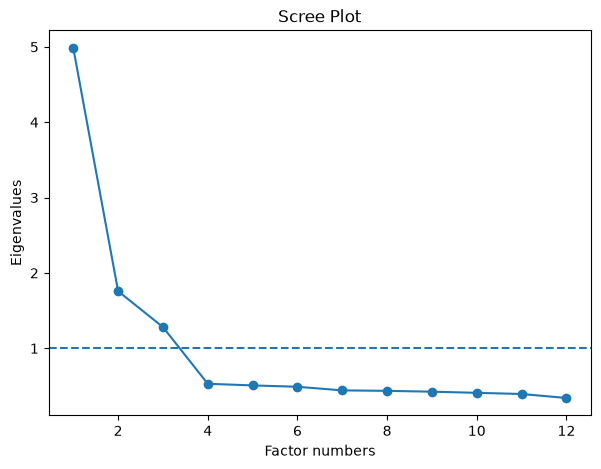

In [48]:
# Make a scree plot to decide how many factors to keep
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(eigenvalue) + 1),
    eigenvalue,
    marker="o"
)

# draw the Kaiser rule line where the eigenvalue equals 1
plt.axhline(
    y=1,
    linestyle="--"
)

plt.xlabel("Factor numbers")
plt.ylabel("Eigenvalues")
plt.title("Scree Plot")

plt.show()

In [49]:
# Run an Exploratory Factor Analysis using 3 factors.
factor_model = Factor(
    corr=R,
    n_factor=3,
    method="pa",
    smc=True,
    nobs=n
)

factor_result = factor_model.fit()

loadings = factor_result.loadings

# Use an oblimin rotation so the factor pattern is easier to read.
rotated_loadings, rotation_matrix = rotate_factors(
    loadings,
    "oblimin",
    0,
    "oblique"
)

# Sort the factors in this order: Role overload, Burnout, Job satisfaction.
rotated_loadings = rotated_loadings[
    :, [2, 0, 1]
]

# Change the signs of the factor loadings when needed so the results are easier to understand.
rotated_loadings = rotated_loadings * -1

In [50]:
# Make a factor loading matrix with labels.
item_names = [
    "RO1 – Too much work",
    "RO2 – Workload is fair (R)",
    "RO3 – Never enough time",
    "B1 – Emotionally drained",
    "B2 – Used up at end of day",
    "B3 – Feel energetic (R)",
    "B4 – Burned out",
    "B5 – Frustrated by job",
    "JS1 – Overall satisfied",
    "JS2 – Job is meaningless (R)",
    "JS3 – Sense of pride",
    "JS4 – Job is enjoyable"
]

# Show a table of the factor loading for each item.
pattern_matrix = pd.DataFrame(
    rotated_loadings,
    index=item_names,
    columns=[
        "Role overload",
        "Burnout",
        "Job satisfaction"
    ]
)

# Round every factor loading to three digits after the decimal point.
pattern_matrix.round(3)

,Role overload,Burnout,Job satisfaction
RO1 – Too much work,0.761,-0.041,-0.031
RO2 – Workload is fair (R),0.686,0.025,-0.015
RO3 – Never enough time,0.704,0.054,0.038
B1 – Emotionally drained,0.024,0.772,0.041
B2 – Used up at end of day,0.067,0.717,0.012
B3 – Feel energetic (R),-0.019,0.797,0.057
B4 – Burned out,-0.008,0.712,-0.086
B5 – Frustrated by job,-0.025,0.688,-0.109
JS1 – Overall satisfied,0.002,-0.064,0.684
JS2 – Job is meaningless (R),0.015,0.007,0.788


In [51]:
### H7 Interpretation

# An exploratory factor analysis was run on 12 items about role overload, burnout, and job satisfaction. 
# The KMO value came out to 0.896. This suggests the data were a good fit for factor analysis.

# Bartlett’s test of sphericity was also significant. The result was χ²(66) = 1519.877 with p less than .001. 
# This means the item correlations were strong enough to proceed with the factor analysis.

# Next, I checked the eigenvalues. Three factors were kept because their eigenvalues were above 1. 
# They were 4.985, 1.759, and 1.282. Together, these three factors accounted for 66.879% of the total variance. The scree plot matched this outcome and also pointed to three factors.

# After rotation, the factor loadings looked clean. Items about role overload linked most strongly with the first factor. 
# Items for burnout aligned most with the second factor. Items about job satisfaction aligned most with the third factor.

# So, H7 is supported. The 12 items appear to reflect three separate underlying factors. 
# These factors fit the role overload, burnout, and job satisfaction scales that were planned.

In [52]:
# Seven hypotheses were supported.  
# The results show clear gaps in burnout and technology adoption.  

# They also show links between the key variables.  
# There were useful predictive ties to employee productivity.  

# The EFA backed a three-part structure.  
# It fit Role Overload, Burnout, and Job Satisfaction.